# Intro

* Terms and parameters of training embeddings
* How to create datasets that can be used to train embeddings

# Parameters

## Inputs and Targets

* **Inputs**: A token sequence
* **Targets**: Sequence shifted by one token

Inputs: $$ \text{You can learn a lot of math with a bit of coding} $$
Targets: $$ \text{can learn a lot of math with a bit of coding} $$

We always try to predict next word in a sequence, then compare pred to true value. So:

* when "You" is input our target is "can"
* when "You can" is input our target is "learn"
* when "You can learn" is input our target is "a"
* when "You can learn a" is input our target is "lot"
* etc.

## Sequence Length

Len = 12: $$ \text{You can learn a lot of math with a bit of coding} $$

Len = 7: $$\text{You can learn a lot of math}$$

It's simply number of tokens we're giving to the model. We want to give longer sequence to provide better context. However, if we have text having 100 000 M tokens, it's probably not beneficial to provide such long sequence.

## Stride

Skip tokens between sequences

Stride 1

$$ \text{You can learn a lot of} $$
$$ \text{can learn a lot of math} $$

we skip 1 word in 2nd sequence. Losses come from token "of" and "math" because we always take loss from last sequence token.

Stride 3

$$ \text{You can learn a lot of} $$
$$ \text{a lot of math with a bit} $$

2nd sequence starts from 3 tokens later.

## Batch Size

Simultaneously processed sequences, we use potential of parallely run gpu's.

Batch 3:

$$ \text{You can learn a lot of math with a bit of coding} $$
$$ \text{Time doesn't wait; move forward or vanish} $$
$$ \text{You can predict your future by napping through it} $$

# Dataset and DataLoader

1. Import text, split into words, create vocab
2. Create input-target sequences
3. Define a Dataset class as input to a DataLoader
4. Export pytorch-ready tokens

## Imports

In [2]:
# typical libraries...
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# for importing and working with texts
import requests
import re
import string

# pytorch stuff
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F

!pip install torchinfo # not installed by default in colab
from torchinfo import summary

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')


## Text and Dictionary

In [3]:
# get raw text from internet (The Time Machine... yeah I use it a lot :P  )
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
# character strings to replace with space
strings2replace = [ '\r\n\r\nâ\x80\x9c','â\x80\x9c','â\x80\x9d','\r\n','â\x80\x94','â\x80\x99','â\x80\x98','_', ]

# use regular expression (re) to replace those strings with space
for str2match in strings2replace:
  text = re.compile(r'%s'%str2match).sub(' ',text)

# remove non-ASCII characters and numbers, and make lower-case
text = re.sub(r'[^\x00-\x7F]+', ' ', text)
text = re.sub('\d+','',text).lower()

# split into words with >1 letter
words = re.split(f'[{string.punctuation}\s]+',text)
words = [item.strip() for item in words if item.strip()]
words = [item for item in words if len(item)>1]

# create the vocabulary (lexicon)
vocab  = sorted(set(words))
n_words = len(words)
n_vocab = len(vocab)

# encoder/decoder look-up-tables (as python dictionaries)
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for i,w in enumerate(vocab)}

# show a few keys in the dictionary
print(f'The book contains {n_words:,} words, {n_vocab:,} of which are unique and comprise the vocab.')
print(f'\n\nFirst 10 vocab words:\n',list(word2idx.keys())[:10])

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1280/3665464753.py:12: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub('\d+','',text).lower()
/tmp/ipykernel_1280/3665464753.py:15: SyntaxWarning: invalid escape sequence '\s'
  words = re.split(f'[{string.punctuation}\s]+',text)


The book contains 30,698 words, 4,589 of which are unique and comprise the vocab.


First 10 vocab words:
 ['abandon', 'abandoned', 'able', 'abnormally', 'abominable', 'abominations', 'about', 'above', 'abruptly', 'absence']


## Dataset

In [4]:
# parameters for dataset
context_length = 8 # context length
stride = 2 # skipping

# initialize
inputs  = []
targets = []

# overlapping sequences of context_length
for i in range(0,n_words-context_length,stride):

  # get a few words
  in_seq   = words[i  : i+context_length  ]
  targ_seq = words[i+1: i+context_length+1]

  # append to the lists
  inputs.append([word2idx[w] for w in in_seq])
  targets.append([word2idx[w] for w in targ_seq])

print(inputs[123])
print(targets[123])

[1342, 4304, 4119, 342, 4296, 3388, 1474, 131]
[4304, 4119, 342, 4296, 3388, 1474, 131, 209]


In [5]:

# a closer look:
print('Inputs: ',inputs[4])
print('Targets:',targets[4])
print('')
print('Inputs :',inputs[5])
print('Targets:',targets[5])
# this is what we need, although we need it in torch Dataset/DataLoader format

Inputs:  [2416, 131, 2172, 506, 4451, 783, 2167, 2005]
Targets: [131, 2172, 506, 4451, 783, 2167, 2005, 4042]

Inputs : [2172, 506, 4451, 783, 2167, 2005, 4042, 2416]
Targets: [506, 4451, 783, 2167, 2005, 4042, 2416, 2006]


In [6]:

# we need each list to be a tensor
torch.tensor(inputs[4])

tensor([2416,  131, 2172,  506, 4451,  783, 2167, 2005])

In [7]:
# create a class for a dataset
class WordDataset(Dataset):
  def __init__(self, text, word2idx, context_length=8, stride=4):

    # initialize
    self.inputs  = []
    self.targets = []
    self.word2idx = word2idx  # stored locally in the object

    # overlapping sequences of context_length
    for i in range(0,len(text)-context_length,stride):

      # get a few words
      in_seq   = text[i   : i+context_length]
      targ_seq = text[i+1 : i+context_length+1]

      # append to the lists
      self.inputs.append(torch.tensor([word2idx[w] for w in in_seq]))
      self.targets.append(torch.tensor([word2idx[w] for w in targ_seq]))

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]


# create an instance!
context_length = 6 # context length
stride = 3 # skipping over tokens
text_dataset = WordDataset(words,word2idx,context_length,stride)

text_dataset[4]

(tensor([4451,  783, 2167, 2005, 4042, 2416]),
 tensor([ 783, 2167, 2005, 4042, 2416, 2006]))

In [8]:
inputs10, outputs10 = text_dataset[10]
inputs10, outputs10

(tensor([4356, 4042, 3937, 2731, 2438, 4362]),
 tensor([4042, 3937, 2731, 2438, 4362, 3915]))

## DataLoader

In [9]:
# also need a dataloader
dataloader = DataLoader(
                text_dataset,
                batch_size = 32, # 2 for looking; 32 for training
                shuffle    = True,
                drop_last  = True
            )

# let's have a look at the indices
X,y = next(iter(dataloader))
print('Inputs:')
print(X), print('')

print('Targets:')
print(y), print('\n\n\n')

# and the words
print('Inputs in words (first batch):')
print([idx2word[item.item()] for item in X[0]])
print('')

print('Targets in words (first batch):')
print([idx2word[item.item()] for item in y[0]])

Inputs:
tensor([[4169, 4092, 4109, 3183,  137, 4201],
        [2453, 1420, 2783,  501, 4042, 2424],
        [4119, 4042, 2739, 1567, 2420, 4458],
        [4408, 4042, 4064, 4041, 3881, 2470],
        [4066,  137, 1902, 4577, 4119,  131],
        [3934, 3693, 2593, 4408, 2309, 2731],
        [ 602, 3144, 4041, 1984, 1640, 4042],
        [4042,  484, 2239, 4047, 2608, 1382],
        [4058, 4454, 3259, 2186, 1815, 2586],
        [4092, 4042,  497, 4144, 4042, 1918],
        [4581,  664, 4119, 4252, 4041, 4073],
        [3527,  496, 2163, 4007, 4058, 4454],
        [3734, 3330,  137, 2309, 4428,  522],
        [3330, 2698, 1868, 3388, 4042, 3850],
        [3363, 2186, 1651,  230, 2003, 4042],
        [3282, 4119, 1937, 2791, 4042,   61],
        [  26, 2186,  230,  131, 4239, 3342],
        [2731, 3487, 2819, 1815, 2741, 3468],
        [ 600, 1640,  162, 1815, 1935, 3468],
        [ 137,  611,  137, 4295, 4042, 1918],
        [ 162, 2731, 4304, 3388, 4352, 2593],
        [2041, 3913,  227,

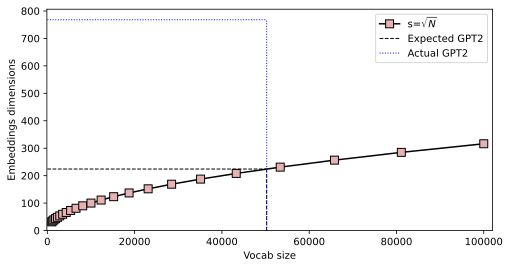

In [10]:

# exploring dimensionality based on vocab sizes

# vocab sizes
N = np.logspace(np.log10(1000),np.log10(100000),23)

# heuristic for non-LLM models like word2vec or glove:
embdim = np.sqrt(N)

# parameters for GPT2
gpt2dims = [ 50257,768 ]

plt.figure(figsize=(8,4))

# heuristic line
plt.plot(N,embdim,'ks-',markersize=8,markerfacecolor=[.9,.7,.7],label=r's=$\sqrt{N}$')

# expected embedding dim for GPT2
plt.plot([gpt2dims[0],gpt2dims[0]],[0,np.sqrt(gpt2dims[0])],'k--',linewidth=1,label='Expected GPT2')
plt.plot([0,gpt2dims[0]],[np.sqrt(gpt2dims[0]),np.sqrt(gpt2dims[0])],'k--',linewidth=1)

# actual GPT2 embedding
plt.plot([gpt2dims[0],gpt2dims[0]],[0,gpt2dims[1]],'b:',linewidth=1,label='Actual GPT2')
plt.plot([0,gpt2dims[0]],[gpt2dims[1],gpt2dims[1]],'b:',linewidth=1)

plt.gca().set(xlabel='Vocab size',ylabel='Embeddings dimensions',
              xlim=[-100,N[-1]+2000],ylim=[0,None])
plt.legend()
plt.show()

# Model to Learn Embeddings

* Some common heuristics for embeddings matrices
* The architecture of a model that learns embeddings
* How embeddings models generate text

**Why do we need a deep learning model?**

* Embeddings matrices are learned from data
* A DL "helper" model is used to help train the embeddings based on next-token prediction
* After training, the embeddings are kept and the helper model is discarded
* Embeddings is specific for vocab size, the helper model additionally depend on sequence length
* Helper hiden layers squeeze the dimensionality, forcing the model to learn dense representations

## Dimensionality of the embeddings space

$$ \text{Input Text (one-hot)} (\text{sequence length}, 4589) \rightarrow \text{Embeddings}\;d(4589, 100) \rightarrow \text{Hidden}\;d(600, 128) \rightarrow \text{Output}\;d(128,4589) $$

## Net Intuition

* Our input is a text, or rather a sequence with predefined length. We input a one-hot encoded input sequence.

* Embeddings is exactly same thing as WTE in GPT2, here we just have smaller dimensions. $(4589, 100)$ means our vocab size is 4589 tokens, where each token is represented with 100 dimensions. As we can see, the core beauty of this model is that Embeddings are actually **Weights** that are being updated during backpropagation. The question is how the model knows that, e.g., row 1234 is token "update"? Well, that's due to the tokenizer. The word "update" in our exemplary tokenizer has token 1234, and is always used in input as 1234, but with context the word "update" would be used. That's how embeddings are created and we know what they mean, or rather which row corresponds to which token.

* Hidden has 600 inputs and 128 outputs. Why 600 input dimensions and not 100? That's because we have sequence length, in this example we have sequence length of 6, so $$100 \times 6 = 600$$

* Output has 128 inputs and 4589 outputs. The question is, why do we have 4589 as output? Well, that's the number of the whole vocab (unique words in the corpus). The model tries to predict which word is next, from 4589 tokens available. Therefore, it's like a classification model trying to find 1 class, but applied multiple times over time. The fun fact is that a simple classification model tries to classify between a couple of classes... once. However, here we don't play around but do classification over 4589 classes at every single time step $t$. The computational cost, in comparison to simple classification, is enormously larger.

## Autoencoder resemblance

This resembles autoencoder in its architecture, at actually nets architecture is exactly like autoencdores. The main difference lies in Loss:

* Autoencoder loss: $L(x', x)$
* Language Modelling loss: $L\,\Big(P(x_{t+1}\,|\,x_{\leq t}),x_{t+1}\Big)$

Autoencoder optimizes loss to recreate output as closely to input as its possible. Embeddings space tries to minimize loss between predicted next word (prediction based on all past words) and true next word.

In other words:

* Autoencoder learns how to represent the data
* Language Model learns how to model data dynamics in time

## Heuristic

* A common heuristic in NLP dimensionality is $\sqrt{N}$ where $N$ is vocab size
* LLMs need much higher dimensionality, because embedding dimensionality constrains Transformer dimensionality

> By default, the length of the embedding vector is 1536 for text-embedding-3-small or 3072 for text-embedding-3-large . To reduce the embedding's dimensions without losing its concept-representing properties, pass in the dimensions parameter.

https://platform.openai.com/docs/guides/embeddings/


In [11]:

# dimensionality of embedding space (arbitrarily set to 100)
embeddingDimension = 100

# create a random embedding
embedding_layer = nn.Embedding(n_vocab,embeddingDimension)

# let's see its size
embedding_layer.weight.shape

torch.Size([4589, 100])

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1280/38710778.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(N,embdim,'ks-',markersize=8,markerfacecolor=[.9,.7,.7],label='$s = \sqrt{N}$')


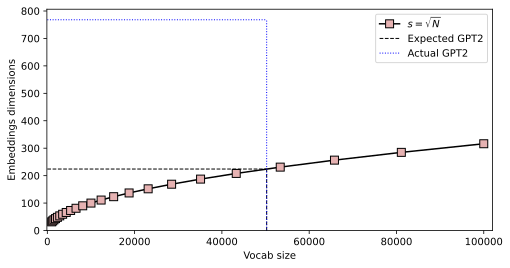

In [12]:
#  exploring dimensionality based on vocab sizes

# vocab sizes
N = np.logspace(np.log10(1000),np.log10(100000),23)

# heuristic for non-LLM models like word2vec or glove:
embdim = np.sqrt(N)

# parameters for GPT2
gpt2dims = [ 50257,768 ]

plt.figure(figsize=(8,4))

# heuristic line
plt.plot(N,embdim,'ks-',markersize=8,markerfacecolor=[.9,.7,.7],label='$s = \sqrt{N}$')

# expected embedding dim for GPT2
plt.plot([gpt2dims[0],gpt2dims[0]],[0,np.sqrt(gpt2dims[0])],'k--',linewidth=1,label='Expected GPT2')
plt.plot([0,gpt2dims[0]],[np.sqrt(gpt2dims[0]),np.sqrt(gpt2dims[0])],'k--',linewidth=1)

# actual GPT2 embedding
plt.plot([gpt2dims[0],gpt2dims[0]],[0,gpt2dims[1]],'b:',linewidth=1,label='Actual GPT2')
plt.plot([0,gpt2dims[0]],[gpt2dims[1],gpt2dims[1]],'b:',linewidth=1)

plt.gca().set(xlabel='Vocab size',ylabel='Embeddings dimensions',
              xlim=[-100,N[-1]+2000],ylim=[0,None])
plt.legend()
plt.show()

So, GPT2 has way more embedding dimensions than it should - at least according to our heuristic $dim = \sqrt{N}$. Why is that?

GPT2 needs a much higher-dimensional embedding space because it is not learning static word representations, but dynamic, context-dependent transformations of information across layers.

* Not just words → computation substrate: embeddings are not final representations but inputs to a sequence of transformations (attention + MLP).

* Context encoding: each token vector must carry information about interactions with other tokens, not just its identity.

* Superposition: many features are stored in overlapping directions, so higher
𝑑
d allows packing more concepts into the same space.

* Expressivity for circuits: larger dimension gives room for multiple parallel mechanisms (circuits) to operate without interference.

* Conclusion: GPT-2 uses higher dimensionality not to store more “words”, but to enable rich, compositional, and dynamic representations of context.

## Random Embeddings

### Create and explore an embedding layer

In [13]:
embedding_dimension = 100
embedding_layer = nn.Embedding(n_vocab, embedding_dimension)
embedding_layer.weight.shape

torch.Size([4589, 100])

### Embedding of random word

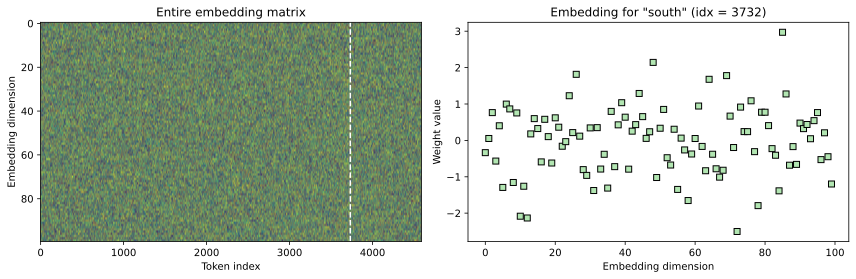

In [14]:
# what does it look like?

_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].imshow(embedding_layer.weight.detach().T,aspect='auto',vmin=-1,vmax=1)
axs[0].set(ylabel='Embedding dimension',xlabel='Token index',title='Entire embedding matrix')

# pick a word at random
aRandomWord = np.random.choice(vocab)

# plot its embedding
axs[1].plot(embedding_layer.weight.detach()[word2idx[aRandomWord],:],'ks',markerfacecolor=[.7,.9,.7])
axs[0].axvline(word2idx[aRandomWord],color='w',linestyle='--')
axs[1].set(xlabel='Embedding dimension',ylabel='Weight value',title=f'Embedding for "{aRandomWord}" (idx = {word2idx[aRandomWord]})')

plt.tight_layout()
plt.show()

### Embeddings for closely related words

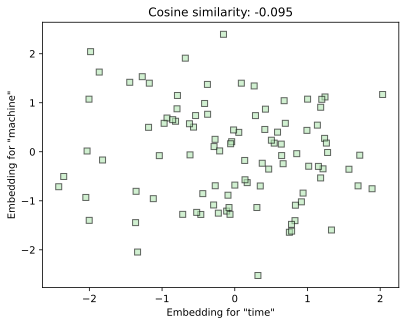

In [15]:

# embeddings for closely related words
word1 = 'time'
word2 = 'machine'

# their embeddings
embed1 = embedding_layer.weight.detach()[word2idx[word1],:]
embed2 = embedding_layer.weight.detach()[word2idx[word2],:]

# cosine similiarity between them
cosSim = torch.dot(embed1,embed2)/(torch.norm(embed1)*torch.norm(embed2))

# vizualize
plt.plot(embed1,embed2,'ks',markerfacecolor=[.7,.9,.7],alpha=.6)
plt.gca().set(xlabel=f'Embedding for "{word1}"',ylabel=f'Embedding for "{word2}"',
              title=f'Cosine similarity: {cosSim:.3f}')
plt.show()

## Embeddings Training Class

In [16]:
class EmbeddingModel(nn.Module):
  def __init__(self, vocab_size, embedding_dim, context_size):
    super(EmbeddingModel, self).__init__()

    # embedding layer
    self.embeddings = nn.Embedding(vocab_size, embedding_dim)

    # linear layers
    self.linear1 = nn.Linear(context_size * embedding_dim, 128)
    self.linear2 = nn.Linear(128, vocab_size)

  def forward(self, inputs):

    # extract and flatten embeddings [batch_size, context_size * embedding_dim]
    embeds = self.embeddings(inputs).view(inputs.shape[0],-1)

    # fully connected layers
    out = F.relu(self.linear1(embeds))
    out = self.linear2(out)

    # log softmax for classification (note: NLLLoss expects logprobs as inputs)
    log_probs = F.log_softmax(out, dim=1)
    return log_probs


# create a model instance!
model = EmbeddingModel(vocab_size=n_vocab, embedding_dim=embeddingDimension, context_size=context_length)
print(model)

# apply Xavier weight distribution
for param in model.parameters():
  if param.dim()>1: # also excludes biases
    nn.init.xavier_normal_(param)

EmbeddingModel(
  (embeddings): Embedding(4589, 100)
  (linear1): Linear(in_features=600, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=4589, bias=True)
)


Let's remember that CrossEntropyLoss takes as input raw logits, i.e. raw calculations ascribed to each class. In our code, the `out` variable is the proper input to CrossEntropyLoss. However, in large models we often use `NLLLoss`, which takes log-probabilities as input, so we apply `log_softmax` to the logits to prepare them for `NLLLoss`. It is also worth noting that we do not use simple `softmax`, but `log_softmax`, because it provides better numerical stability.

### Single Iter

In [17]:
# let's test the model

X,y = next(iter(dataloader))
model_out = model(X)

print('Input to model:')
print(X), print('')

print(f'Output from model (size: {list(model_out.detach().shape)}):')
print(model_out)

Input to model:
tensor([[3388, 4119, 2609,  709, 2163, 4042],
        [4572,   81,  137, 4042, 2132, 4041],
        [ 501,  230, 2186, 4408, 4042, 4064],
        [4042,  329, 2887, 2586, 1934,  137],
        [1173, 2608, 1492, 4389, 2347, 4042],
        [1901, 1835, 4467, 3704,  493, 2458],
        [4042, 3140, 1815, 2395, 2187, 2439],
        [4042, 1526, 2930,  137, 2731, 2608],
        [3078, 2766, 3250, 2382, 1663, 2731],
        [2435, 4316, 4510, 2608, 2459,  137],
        [4042,  294,  644, 4041, 4408,  255],
        [1815, 2698,  686, 4119, 4042, 2031],
        [1929, 4528, 2041, 1870,  137, 4073],
        [2386, 2608,  643, 1408, 2041, 4042],
        [2821, 2746, 3455,  137, 4352, 3765],
        [3945, 2186, 4408, 4058, 4481, 1815],
        [4042, 3758, 4408, 4144, 2186,  522],
        [1618, 2041, 4230, 1039,  501, 1971],
        [2035, 4041,  817, 3000, 1894, 4119],
        [1607,  845, 4481, 1815, 1584, 4043],
        [ 137,  817, 3460,  131, 4255,  851],
        [4119,  31

### Output

In [18]:

# log soft-max output:
print(model_out.detach()[0])
print('')

# shouldn't the sum be 1?
print(f'Log softmax sum = {model_out.detach()[0].sum():.3f}')

# ah, it's *log* softmax :D
print(f'exp(log(softmax)) sum = {torch.exp(model_out.detach()[0]).sum():.3f}')

tensor([-8.4073, -8.4041, -8.4970,  ..., -8.4541, -8.4800, -8.4942])

Log softmax sum = -38697.773
exp(log(softmax)) sum = 1.000


### Highest Prob Word and True Word

In [19]:
print('Model input:')
print([idx2word[w.item()] for w in X[0]])
print('')

print('Model output:')
print(idx2word[model_out[0].argmax().item()])

print('')
print('True Pred:')
print(idx2word[y[0][-1].item()])

Model input:
['said', 'to', 'myself', 'come', 'into', 'the']

Model output:
malachite

True Pred:
future


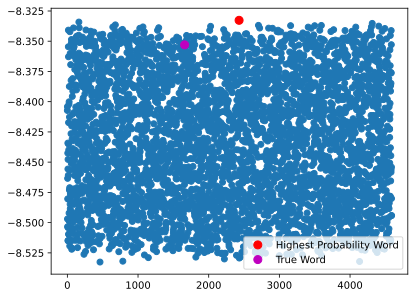

In [20]:
plt.plot(model_out[0].detach(),'o')
plt.plot(model_out[0].argmax().item(), model_out[0].max().item(), 'ro', markersize = 8, label = 'Highest Probability Word')

true_word_idx = y[0][-1].item()

plt.plot(true_word_idx, model_out[0][true_word_idx].detach(), 'mo', markersize = 8, label = 'True Word')
plt.legend(loc = 'lower right')

plt.show()

### Have the model generate the text

In [21]:
# grab some data from the loader
X,y = next(iter(dataloader))

print('First input:')
print(' '.join([idx2word[w.item()] for w in X[0]]))
print('\nSubsequent inputs:')

# text generation
for _ in range(context_length):

  # get output for this input
  Y = model(X)

  # pick the most likely next word
  nextWord = Y[0].argmax().item()

  # create new input for the next iteration (word)
  X[0] = torch.concatenate((X[0][1:],torch.tensor([nextWord])))

  # print out the generated text so far
  print(' '.join([idx2word[w.item()] for w in X[0]]))

First input:
uniformly curly came to sharp end

Subsequent inputs:
curly came to sharp end part
came to sharp end part perplexity
to sharp end part perplexity crackling
sharp end part perplexity crackling estuary
end part perplexity crackling estuary estuary
part perplexity crackling estuary estuary rigorous


### Summary

In [22]:

# summary of model and parameters
summary(model, input_data=X, col_names=['input_size','output_size','num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
EmbeddingModel                           [32, 6]                   [32, 4589]                --
├─Embedding: 1-1                         [32, 6]                   [32, 6, 100]              458,900
├─Linear: 1-2                            [32, 600]                 [32, 128]                 76,928
├─Linear: 1-3                            [32, 128]                 [32, 4589]                591,981
Total params: 1,127,809
Trainable params: 1,127,809
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 36.09
Input size (MB): 0.00
Forward/backward pass size (MB): 1.36
Params size (MB): 4.51
Estimated Total Size (MB): 5.87

## Loss function to train the embeddings

* The loss function used to train embeddings and LLMs
* Why negative log likelihood is the right loss, and how it works (in math and in PyTorch)
* How to evaluate loss functions in small examples

### What is a loss function?

* A Loss function is a mathematical expression of the discrepancy between the model's output and the target value
* The goal of gradient descent is to minimize the loss function
* There are several loss functions depending on the nature of the data and the goal of the model
* Loss function are usually very simple mathematically, but are impossible to solve analytically in large models.

$$w \leftarrow \eta\;\partial L $$

Examples:

* $$ L = \frac{1}{2}(\overset{\wedge}{y}- y)^2 $$
* $$ L = -\Big(y\,log(\overset{\wedge}{y}) + (1-y)\,log(1-\overset{\wedge}{y})\Big) $$
* $$ L = \sum_{x} p(x)\,log\Big(\frac{p(x)}{q(x)}\Big) $$

### LM Loss Functio

**NLLLoss**

Negative log-likelihood is used for categorization tasks (same as cross-entropy). Let's remember that going through text (which is sequence) we try to predict next word (or token). However, we dont take next word (or rather token) out of the blue, we pick most probable word from whole vocab, i.e. this is basically classification task repeated along the sequence.

$$NLLLoss = L = -\Big(y\,log(\overset{\wedge}{y}) + (1-y)\,log(1-\overset{\wedge}{y})\Big) = - \sum_{i=1}^N \sum_{k=1}^C y_i^{(k)}\,ln(\overset{\wedge}{y}_i^{(k)}) = -\,ln(\overset{\wedge}{y}^{(k)})$$

As we said, we classify the next token, so we have $C$ classes equal to the vocabulary size. The value of $N$ depends on how the loss is computed: if we compute it only for the last token, then effectively $N=1$ per sequence, allowing the model to first accumulate information from previous tokens; otherwise, $N$ corresponds to all predicted tokens in the sequence.

Okay, so why did we drop some symbols:

* $\sum_{i=1}^N$ — this is dropped only if we compute the loss for a single sample (e.g., one token), so effectively $N=1$. It has nothing to do with one-hot encoding. This is a design choice; if we compute the loss over multiple tokens or samples, this term remains.

* $\sum_{k=1}^C$ — this term comes from summing over all classes (vocabulary tokens). Because the target $y$ is one-hot encoded, only one term in the sum is non-zero (the true token has value 1, all others are 0). Therefore, the sum reduces to a single term:
$-\ln(\hat y^{(k_{true})})$. This is not a design choice but a direct consequence of the one-hot representation of the target.

* $y_i^{(k)}$ — for sample $i$, this indicates whether class (token) $k$ is the correct one. In practice, this is a one-hot value: it is 1 for the true token and 0 for all other tokens.


The core intuition is that we have only one correct next token in the target, which is why all sums over classes and $y_i^{(k)}$ reduce to a single term. If we designed the task so that multiple tokens were correct at once (e.g., 5 tokens), then those terms would not disappear, and we would need to compute the loss over all of them with traditional NLLLoss - of course we still use traditional NLLLoss, but from computation perspective the formula is much simplified as we proved above.


**One Note**: CrossEntropyLoss takes raw logits as input; NLLLoss takes log-softmax

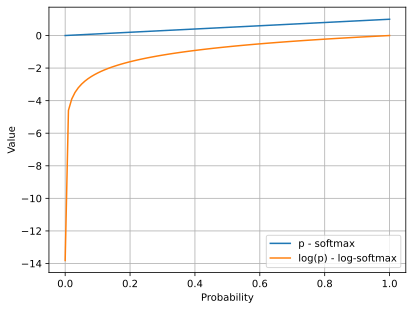

In [23]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(1e-6, 1, 100)

log_p = np.log(p)

plt.plot(p, p, label='p - softmax')
plt.plot(p, log_p, label='log(p) - log-softmax')

plt.xlabel("Probability")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

Log-softmax provides stronger and more informative gradients, especially when the model assigns low probability to the correct class. This leads to faster and more stable learning. Its benefit is not simply non-linearity, but the way it amplifies errors for incorrect confident predictions.

### $p \text{ vs } log(p)$

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

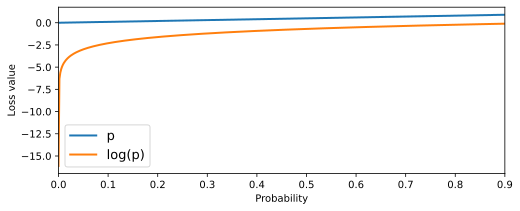

In [25]:
p = np.linspace(.0000001, .9, 500)

plt.figure(figsize = (8,3))
plt.plot(p,p,label = 'p', linewidth = 2)
plt.plot(p, np.log(p), label = 'log(p)', linewidth=2)
plt.gca().set(xlabel = 'Probability', ylabel = 'Loss value', xlim = [0,p[-1]])

plt.legend(fontsize=13)
plt.show()

In [26]:
# create a loss function instance
loss_function = nn.NLLLoss()
dir(loss_function)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_non_per

### Beauty of Softmax

Out best outcome from model_output is on index 1 since its the highest (2.3). Now, log_softmax returns loss of 0.14 when correct output is on index "1". Why not 0.0 if model was right? Let's change setup a bit.

In [27]:
# start with three outputs (raw model outputs for three tokens in the vocab)
model_output = torch.tensor([[-1,2.3,2.1]],dtype = torch.float64)
print('Raw model outputs:')
print(f'  {model_output[0].tolist()}\n')

# NLLLoss expects log-softmax inputs
logsoftmax_output = F.log_softmax(model_output, dim = -1)
print('Log-softmax model outputs:')
print(' ', [round(o.item(), 2) for o in logsoftmax_output[0]], '\n')

# check the loss for different targets
for target in range(len(model_output[0])):
  # which output is the target (correct response)?
  target = torch.tensor([target])

  # calculate the loss
  theloss = loss_function(logsoftmax_output, target)

  # and print
  print(f'When the correct output is index "{target.item()}", the loss is {theloss.item():.2f}')

Raw model outputs:
  [-1.0, 2.3, 2.1]

Log-softmax model outputs:
  [-3.92, -0.62, -0.82] 

When the correct output is index "0", the loss is 3.92
When the correct output is index "1", the loss is 0.62
When the correct output is index "2", the loss is 0.82


Now, we've changed 0.1 to 2.1, still 2.3 is highest values. However, loss is bigger. Softmax, works in a way that even though our model predicts correct class it takes into account rest classes. Loss says that "you did well" but you need to try harder, because you evaluated wrong class to high, so you're not confident enough.

### Multi-sample losses (for batches)

In [28]:
# let's create four batches
batch_output = model_output.repeat(4,1)
# print(batch_output, '\n')

# but of course we need logsoftmax
logsoftmax_output = F.log_softmax(batch_output, dim = 1)
print(logsoftmax_output), logsoftmax_output.shape

tensor([[-3.9182, -0.6182, -0.8182],
        [-3.9182, -0.6182, -0.8182],
        [-3.9182, -0.6182, -0.8182],
        [-3.9182, -0.6182, -0.8182]], dtype=torch.float64)


(None, torch.Size([4, 3]))

In [29]:
# target changes for each batch
targets = torch.tensor([0,1,2,0])
targets

tensor([0, 1, 2, 0])

In [30]:
loss = loss_function(logsoftmax_output, targets)
print(loss)

tensor(2.3182, dtype=torch.float64)


In [31]:
# again, manual calculation
-torch.tensor([-3.9182+-0.6182+-0.8182-3.9182])/len(targets)

tensor([2.3182])

In [32]:
# loss.backward()

### Simple example in pytorch

In [33]:
#  define a weight matrix (requires_grad=True to track gradients)
w = torch.tensor([[-1,.2]], requires_grad=True)

# target category
target = torch.tensor([0])

# optimizer
optimizer = torch.optim.SGD([w],lr=.5)

# training iterations
numTrainingIters = 10

# initialize some variables
allWeights      = torch.zeros((numTrainingIters+1,2))
allWeights[0,:] = w.detach()
allLosses       = torch.zeros(numTrainingIters)

# training loop
for i in range(numTrainingIters):

  # reset gradients
  optimizer.zero_grad()

  # model outputs (simulating a full model forward pass ;)  )
  modeloutput = F.log_softmax(w,dim=1)

  # loss
  loss = loss_function(modeloutput,target)
  allLosses[i] = loss.item()

  # gradient descent
  loss.backward()  # calculate gradient of loss wrt w
  optimizer.step() # adjust w using SGD

  # store the new weights
  allWeights[i+1,:] = w.detach()

  # and print out some results
  print(f"Step {i+1:2d}: loss = {loss.item():.3f}, weights = {[round(o.item(),2) for o in w[0] ]}")

Step  1: loss = 1.463, weights = [-0.62, -0.18]
Step  2: loss = 0.932, weights = [-0.31, -0.49]
Step  3: loss = 0.610, weights = [-0.08, -0.72]
Step  4: loss = 0.427, weights = [0.09, -0.89]
Step  5: loss = 0.319, weights = [0.23, -1.03]
Step  6: loss = 0.252, weights = [0.34, -1.14]
Step  7: loss = 0.206, weights = [0.43, -1.23]
Step  8: loss = 0.174, weights = [0.51, -1.31]
Step  9: loss = 0.150, weights = [0.58, -1.38]
Step 10: loss = 0.132, weights = [0.64, -1.44]


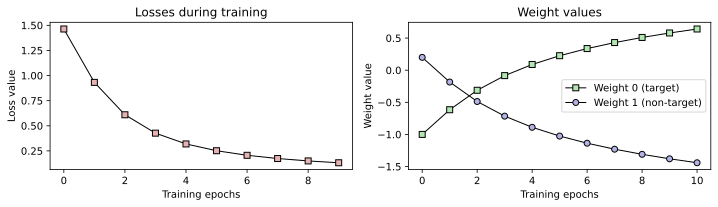

In [34]:
# let's see the weights!
_,axs = plt.subplots(1,2,figsize=(10,3))

axs[0].plot(allLosses,'ks-',linewidth=1,markerfacecolor=[.9,.7,.7])
axs[0].set(xlabel='Training epochs',ylabel='Loss value',title='Losses during training')

axs[1].plot(allWeights[:,0],'ks-',markerfacecolor=[.7,.9,.7],linewidth=1,label='Weight 0 (target)')
axs[1].plot(allWeights[:,1],'ko-',markerfacecolor=[.7,.7,.9],linewidth=1,label='Weight 1 (non-target)')
axs[1].set(xlabel='Training epochs',ylabel='Weight value',title='Weight values')
axs[1].legend()

plt.tight_layout()
plt.show()

# Train Embedding

## Init

In [35]:
# we'll use the GPU for speed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Model

In [36]:
# create a fresh model instance
model = EmbeddingModel(vocab_size=n_vocab, embedding_dim=embeddingDimension, context_size=context_length)

# with Xavier weight distribution
for param in model.parameters():
  if param.dim()>1: nn.init.xavier_normal_(param)


# and move it to the GPU
model = model.to(device)

# # create the loss and optimizer functions
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

## Test if model works

In [37]:
model = model.to(device)
# quick test for errors and sanity-check the output matrix sizes
X,y = next(iter(dataloader))
X,y = X.to(device), y.to(device)

# forward pass
modelOutput = model(X)

# check the sizes
print(f'Model input is of size: {X.shape}')
print(f'Target output is of size: {y.shape}')
print(f'Model output is of size: {modelOutput.shape}')

# loss function
loss = loss_function(modelOutput,y[:,-1])
print(f'\nLoss:')
loss

Model input is of size: torch.Size([32, 6])
Target output is of size: torch.Size([32, 6])
Model output is of size: torch.Size([32, 4589])

Loss:


tensor(8.4310, device='cuda:0', grad_fn=<NllLossBackward0>)

## Weights plot

In [38]:
pretrained_embeddings = model.embeddings.weight.detach().cpu().numpy()

## Train

In [39]:
def trainTheModel(model,num_epochs=25):

  # initialize losses
  total_loss = np.zeros(num_epochs)

  for epoch in range(num_epochs):

    # initialize
    epoch_loss = 0

    # loop over batches in the data loader
    for X,y in dataloader:

      # move data to GPU
      X,y = X.to(device), y.to(device)

      # clear previous gradients
      model.zero_grad()

      # forward pass
      log_probs = model(X)

      # calculate the losses from the final target word
      loss = loss_function(log_probs,y[:,-1])

      # backprop
      loss.backward()
      optimizer.step()

      # sum the per-epoch losses
      epoch_loss += loss.item()

    # scale by the number of tokens in this dataloader
    total_loss[epoch] = epoch_loss / len(dataloader.dataset)

    # update our progress :)
    print(f'  Finished epoch {epoch+1} with loss {epoch_loss / len(dataloader.dataset):.4f}')

  # output the model and the losses
  return model,total_loss

  Finished epoch 1 with loss 0.2174
  Finished epoch 2 with loss 0.1881
  Finished epoch 3 with loss 0.1754
  Finished epoch 4 with loss 0.1648
  Finished epoch 5 with loss 0.1546
  Finished epoch 6 with loss 0.1435
  Finished epoch 7 with loss 0.1315
  Finished epoch 8 with loss 0.1177
  Finished epoch 9 with loss 0.1022
  Finished epoch 10 with loss 0.0854
  Finished epoch 11 with loss 0.0668
  Finished epoch 12 with loss 0.0475
  Finished epoch 13 with loss 0.0300
  Finished epoch 14 with loss 0.0170
  Finished epoch 15 with loss 0.0091
  Finished epoch 16 with loss 0.0049
  Finished epoch 17 with loss 0.0026
  Finished epoch 18 with loss 0.0015
  Finished epoch 19 with loss 0.0010
  Finished epoch 20 with loss 0.0006
  Finished epoch 21 with loss 0.0005
  Finished epoch 22 with loss 0.0004
  Finished epoch 23 with loss 0.0003
  Finished epoch 24 with loss 0.0003
  Finished epoch 25 with loss 0.0002


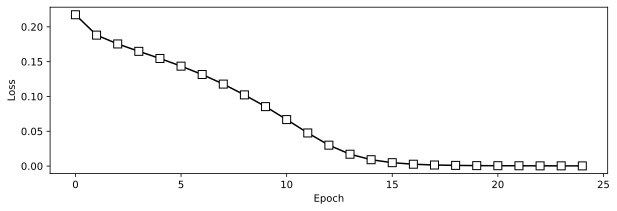

In [40]:
# train the model!
model,total_loss = trainTheModel(model) # using default 25 epochs

# plot the losses
plt.figure(figsize=(10,3))
plt.plot(total_loss,'ks-',markerfacecolor='w',markersize=8)
plt.gca().set(xlabel='Epoch',ylabel='Loss')
plt.show()

# Eval

## Distribution of Embeddings

In [41]:
pretrained_embeddings.shape

(4589, 100)

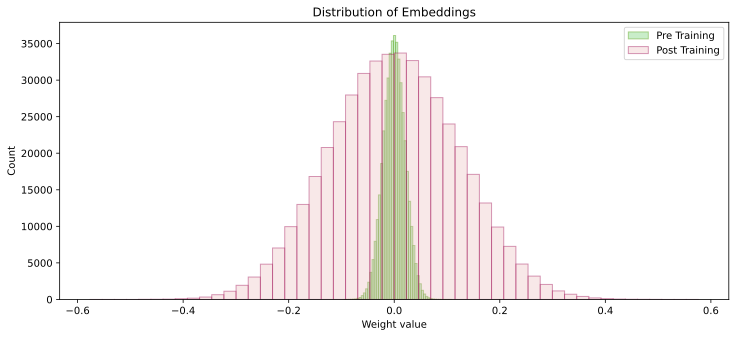

In [42]:
pre_y, pre_x = np.histogram(pretrained_embeddings.flatten(), bins = 50)

trained_embeddings = model.embeddings.weight.detach().cpu()
post_y, post_x     = np.histogram(trained_embeddings.flatten(), bins = 50)

# recalculate x values as bin centers
pre_x = (pre_x[1:]+pre_x[:-1])/2
post_x = (post_x[1:]+post_x[:-1])/2

plt.figure(figsize = (12,5))
plt.bar(pre_x, pre_y, width = pre_x[1]-pre_x[0], color = [.7,.9,.7,.7], edgecolor=[.3,.6,0,.4], label = 'Pre Training')
plt.bar(post_x, post_y, width = post_x[1] - post_x[0], color = [.9,.7,.7,.3], edgecolor = [.6,0,.3,.4], label = 'Post Training')

plt.gca().set(xlabel = 'Weight value', ylabel = 'Count', title = 'Distribution of Embeddings')
plt.legend()
plt.show()

## Embeddings for a random word

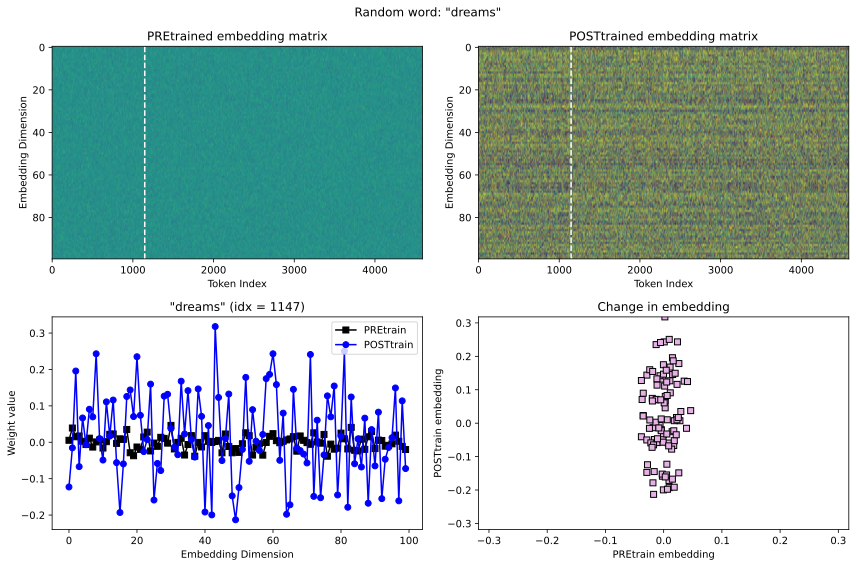

In [43]:
random_word = np.random.choice(n_vocab)

fig, axs = plt.subplots(2,2,figsize = (12,8))

axs[0][0].imshow(pretrained_embeddings.T, aspect = 'auto', vmin = -.1, vmax = .1)
axs[0][0].axvline(random_word, linestyle = '--', color = 'w')
axs[0][0].set_title('PREtrained embedding matrix')

axs[0][1].imshow(trained_embeddings.T, aspect = 'auto', vmin = -.1, vmax = .1)
axs[0][1].axvline(random_word, linestyle = '--', color = 'w')
axs[0][1].set_title('POSTtrained embedding matrix')

for i in range(2):
  axs[0][i].set_xlabel('Token Index')
  axs[0][i].set_ylabel('Embedding Dimension')


axs[1][0].plot(pretrained_embeddings[random_word], 'ks-', label = 'PREtrain')
axs[1][0].plot(trained_embeddings[random_word], 'bo-', label = 'POSTtrain')
axs[1][0].set_title(f'"{idx2word[random_word]}" (idx = {random_word})')
axs[1][0].set_xlabel('Embedding Dimension')
axs[1][0].set_ylabel('Weight value')
axs[1][0].legend()

axs[1][1].plot(pretrained_embeddings[random_word,:], trained_embeddings[random_word,:],'ks', markerfacecolor = [.9,.7,.9])
axlim = max(abs(trained_embeddings[random_word,:]).max(), abs(pretrained_embeddings[random_word,:]).max())
axs[1][1].set_xlim([-axlim, axlim])
axs[1][1].set_ylim([-axlim, axlim])
axs[1,1].set(xlabel = 'PREtrain embedding', ylabel = 'POSTtrain embedding', title = 'Change in embedding')

plt.suptitle(f'Random word: "{idx2word[random_word]}"')

plt.tight_layout()
plt.show()

## "Time" "Machine" Embeddings

/tmp/ipykernel_1280/3499458840.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos_sim_pst = np.dot(time_pst_em, mach_pst_em) / (np.linalg.norm(time_pst_em) * np.linalg.norm(mach_pst_em))


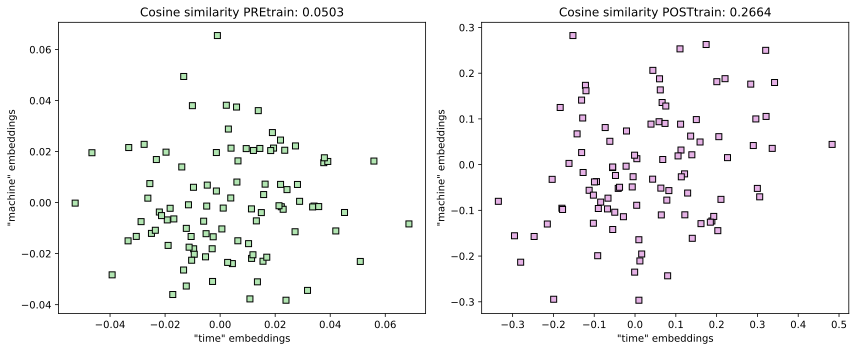

In [44]:
time_wrd = 'time'
mach_wrd = 'machine'

time_idx = word2idx[time_wrd]
mach_idx = word2idx[mach_wrd]

time_pre_em = pretrained_embeddings[time_idx]
mach_pre_em = pretrained_embeddings[mach_idx]

cos_sim_pre = np.dot(time_pre_em, mach_pre_em) / (np.linalg.norm(time_pre_em) * np.linalg.norm(mach_pre_em))

time_pst_em = trained_embeddings[time_idx]
mach_pst_em = trained_embeddings[mach_idx]

cos_sim_pst = np.dot(time_pst_em, mach_pst_em) / (np.linalg.norm(time_pst_em) * np.linalg.norm(mach_pst_em))

fig, axs = plt.subplots(1,2,figsize = (12,5))

axs[0].plot(time_pre_em, mach_pre_em, 'ks', markerfacecolor = [.7,.9,.7])
axs[0].set(xlabel = f'"{time_wrd}" embeddings', ylabel = f'"{mach_wrd}" embeddings', title = f'Cosine similarity PREtrain: {cos_sim_pre:.4f}')

axs[1].plot(time_pst_em, mach_pst_em, 'ks', markerfacecolor = [.9,.7,.9])
axs[1].set(xlabel = f'"{time_wrd}" embeddings', ylabel = f'"{mach_wrd}" embeddings', title = f'Cosine similarity POSTtrain: {cos_sim_pst:.4f}')


plt.tight_layout()
plt.show()

## Embeddings Stability

## Multiple Training Losses

In [45]:
num_exp = 10
num_epochs = 16

losses = torch.zeros(num_exp, num_epochs)
embeddings = torch.zeros(num_exp, pretrained_embeddings.shape[0], pretrained_embeddings.shape[1])

for exp in range(num_exp):
  print(f'\n\nExperiment {exp+1} Running\n\n')

  # create a fresh model instance
  model = EmbeddingModel(vocab_size=n_vocab, embedding_dim=embeddingDimension, context_size=context_length)

  # with Xavier weight distribution
  for param in model.parameters():
    if param.dim()>1: nn.init.xavier_normal_(param)


  # and move it to the GPU
  model = model.to(device)

  # # create the loss and optimizer functions
  loss_function = nn.NLLLoss().to(device)
  optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

  model,total_loss = trainTheModel(model, num_epochs = num_epochs)

  losses[exp] = torch.tensor(total_loss)
  embeddings[exp] = model.embeddings.weight.detach().cpu()



Experiment 1 Running


  Finished epoch 1 with loss 0.2167
  Finished epoch 2 with loss 0.1874
  Finished epoch 3 with loss 0.1748
  Finished epoch 4 with loss 0.1638
  Finished epoch 5 with loss 0.1535
  Finished epoch 6 with loss 0.1425
  Finished epoch 7 with loss 0.1305
  Finished epoch 8 with loss 0.1169
  Finished epoch 9 with loss 0.1010
  Finished epoch 10 with loss 0.0830
  Finished epoch 11 with loss 0.0635
  Finished epoch 12 with loss 0.0437
  Finished epoch 13 with loss 0.0266
  Finished epoch 14 with loss 0.0147
  Finished epoch 15 with loss 0.0077
  Finished epoch 16 with loss 0.0041


Experiment 2 Running


  Finished epoch 1 with loss 0.2170
  Finished epoch 2 with loss 0.1881
  Finished epoch 3 with loss 0.1757
  Finished epoch 4 with loss 0.1647
  Finished epoch 5 with loss 0.1544
  Finished epoch 6 with loss 0.1433
  Finished epoch 7 with loss 0.1312
  Finished epoch 8 with loss 0.1175
  Finished epoch 9 with loss 0.1019
  Finished epoch 10 with loss 0.0849
  Fini

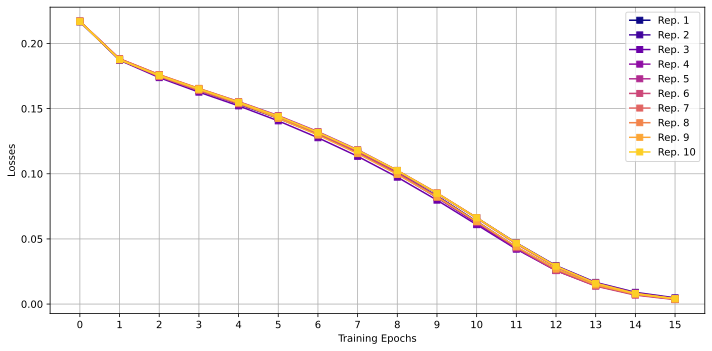

In [46]:
fig = plt.figure(figsize = (10,5))
for exp in range(num_exp):
  plt.plot(losses[exp], 's-',label = f'Rep. {exp+1}', color = mpl.cm.plasma(exp/num_exp))
plt.xlabel('Training Epochs')
plt.ylabel('Losses')
plt.xticks(range(num_epochs))
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Words Embeddings in Mulitple Trainings

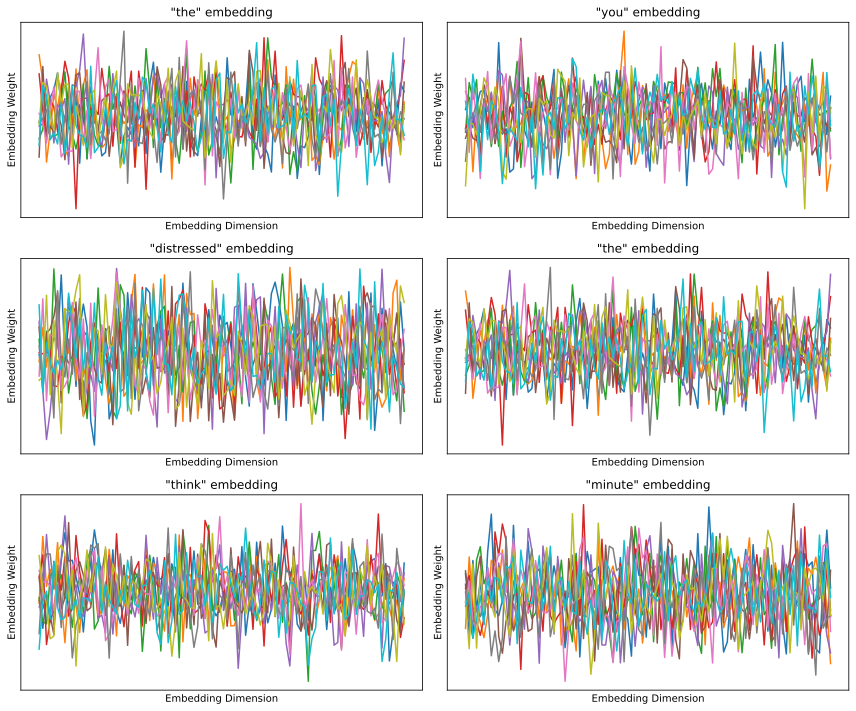

In [47]:
rand_words = np.random.choice(words, 10)

fig, axs = plt.subplots(3,2,figsize = (12,10))

for ax, word in zip(axs.flatten(), rand_words):
  word_idx = word2idx[word]

  for exp in range(num_exp):
    ax.plot(embeddings[exp][word_idx])
    ax.set_title(f'"{word}" embedding')
    ax.set_xlabel('Embedding Dimension')
    ax.set_ylabel('Embedding Weight')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Cos Similarity for Selected Word Pairs

In [56]:
embeddings.shape

torch.Size([10, 4589, 100])

In [87]:
from itertools import combinations

words = ["time", "machine", "she"]
pairs = list(combinations(words, 2))

cos_sims = np.zeros((num_exp, len(pairs)))

for i, (word1, word2) in enumerate(pairs):
    word1_idx = word2idx[word1]
    word2_idx = word2idx[word2]

    for exp in range(num_exp):
        word1_em = embeddings[exp][word1_idx]
        word2_em = embeddings[exp][word2_idx]
        cos_sims[exp, i] = np.dot(word1_em, word2_em) / (
            np.linalg.norm(word1_em) * np.linalg.norm(word2_em)
        )

/tmp/ipykernel_1280/122863127.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos_sims[exp, i] = np.dot(word1_em, word2_em) / (


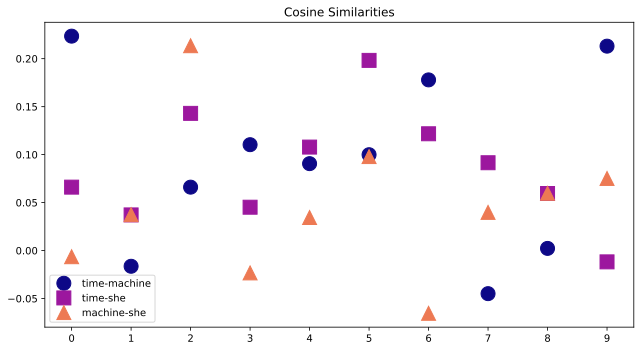

In [96]:
markers = ['o', 's', '^']

plt.figure(figsize=(9,5))
for i, (w1, w2) in enumerate(combinations(words, 2)):
    plt.plot(
        cos_sims[:, i],
        marker=markers[i],
        linestyle='',
        label=f'{w1}-{w2}',
        color=mpl.cm.plasma(i/3),
        markersize = 14
    )

plt.legend()
plt.xticks(range(num_exp))
plt.title('Cosine Similarities')
plt.tight_layout()
plt.show()

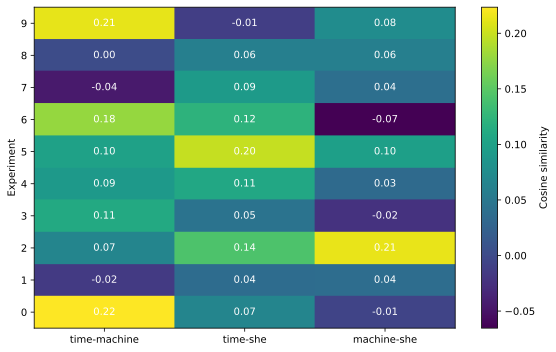

In [86]:
plt.figure(figsize=(8,5))
plt.imshow(cos_sims, aspect='auto', origin='lower')
plt.ylabel('Experiment')
plt.colorbar(label='Cosine similarity')
plt.yticks(range(num_exp))
plt.xticks(range(3), [f'{w1}-{w2}' for w1, w2 in combinations(words, 2)])

for i in range(num_exp):
    for j in range(cos_sims.shape[1]):
        plt.text(j, i, f'{cos_sims[i, j]:.2f}', ha='center', va='center', color = 'w')

plt.tight_layout()
plt.show()